##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
!pip install yt-dlp moviepy

# Download the UCF11 dataset (also known as YouTube Action dataset)
!wget -nc --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
!unrar x UCF11_updated_mpg.rar -inul -y

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.1 MB/s eta 0:00:00:00:01
--2026-04-19 21:12:00--  https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1045106394 (997M) [application/x-rar-compressed]
Saving to: ‘UCF11_updated_mpg.rar’

UCF11_updated_mpg.r 100%[===================>] 996.69M  30.5MB/s    in 34s     

2026-04-19 21:12:35 (29.0 MB/s) - ‘UCF11_updated_mpg.rar’ saved [1045106394/1045106394]



In [2]:
# Install ALL required libraries
!pip install patool yt-dlp opencv-python tensorflow scikit-learn matplotlib -q

import os
import cv2
import random
import urllib.request
import numpy as np
import patoolib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Set random seeds for consistent results
seed_constant = 0
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

# Configuration parameters
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64
SEQUENCE_LENGTH = 20
DATASET_DIR = "UCF11_updated_mpg"
CLASSES_LIST = ["basketball", "biking", "diving"]

# Download and Extract Dataset
rar_file = "UCF11_updated_mpg.rar"
if not os.path.exists(rar_file):
    print("Downloading UCF11 Dataset...")
    urllib.request.urlretrieve("https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar", rar_file)
if not os.path.exists(DATASET_DIR):
    print("Extracting UCF11 Dataset...")
    patoolib.extract_archive(rar_file, outdir=".")

# Data Extraction Functions
def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    if video_frames_count == 0: return frames_list
    
    skip_frames_window = max(int(video_frames_count / SEQUENCE_LENGTH), 1)
    for frame_counter in range(SEQUENCE_LENGTH):
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        success, frame = video_reader.read() 
        if not success: break
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)
    video_reader.release()
    return frames_list

def create_dataset():
    features, labels = [], []
    for class_index, class_name in enumerate(CLASSES_LIST):
        print(f'Extracting frames for Class: {class_name}...')
        class_dir_path = os.path.join(DATASET_DIR, class_name)
        if not os.path.exists(class_dir_path):
            print(f"Directory {class_dir_path} not found. Skipping...")
            continue
            
        for group_folder in os.listdir(class_dir_path):
            group_folder_path = os.path.join(class_dir_path, group_folder)
            if os.path.isdir(group_folder_path):
                for file_name in os.listdir(group_folder_path):
                    if file_name.endswith('.mpg'):
                        frames = frames_extraction(os.path.join(group_folder_path, file_name))
                        if len(frames) == SEQUENCE_LENGTH:
                            features.append(frames)
                            labels.append(class_index)
    return np.array(features), np.array(labels)

# Run Extraction and Split Data
features, labels = create_dataset()
print(f"Total videos processed: {len(features)}")

one_hot_encoded_labels = to_categorical(labels)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels, test_size=0.2, shuffle=True, random_state=seed_constant
)
print(f"Training samples: {len(features_train)} | Testing samples: {len(features_test)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.7 MB/s eta 0:00:00
Extracting frames for Class: basketball...
Extracting frames for Class: biking...
Extracting frames for Class: diving...
Total videos processed: 439
Training samples: 351 | Testing samples: 88


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting Model Training...
Epoch 1/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.3964 - loss: 1.0919 - val_accuracy: 0.3662 - val_loss: 1.0478
Epoch 2/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6143 - loss: 0.8266 - val_accuracy: 0.6761 - val_loss: 0.6427
Epoch 3/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7857 - loss: 0.5899 - val_accuracy: 0.7465 - val_loss: 0.5482
Epoch 4/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8000 - loss: 0.5017 - val_accuracy: 0.8451 - val_loss: 0.4495
Epoch 5/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8429 - loss: 0.4509 - val_accuracy: 0.8028 - val_loss: 0.4860
Epoch 6/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8857 - loss: 0.3426 - val_accuracy: 0.8873 - val_loss: 0.3319
Epoch 7/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8786 - loss: 0.3343 - val_accuracy: 0.8451 - val_loss: 0.3695
Epoch 8/70
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8893 - loss: 0.305

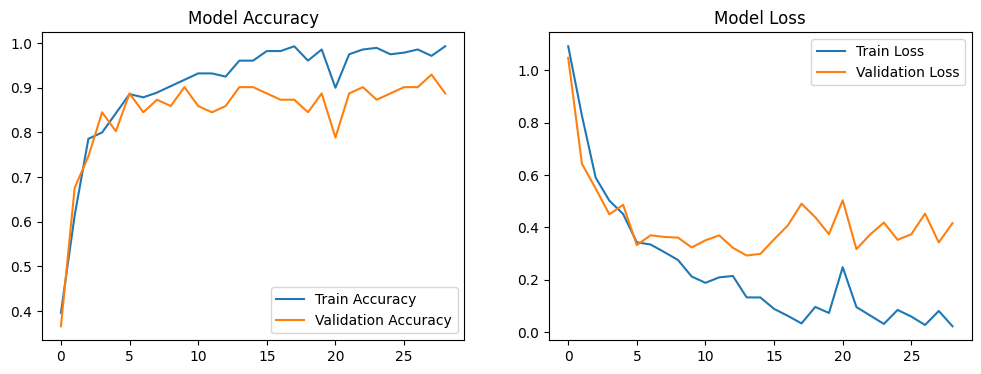

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9659 - loss: 0.1254


Test Accuracy (Best Model): 96.59%
Best Model successfully saved as: HaneenAlhabib_ucf11_model.h5


In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.layers import *
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

def create_lrcn_model():
    model = Sequential()
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'), input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(32))
    model.add(Dense(len(CLASSES_LIST), activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])
    return model

model = create_lrcn_model()

# Train the model (restore_best_weights=True ensures the final saved model is the BEST one)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)
print("Starting Model Training...")
history = model.fit(x=features_train, y=labels_train, epochs=70, batch_size=4, 
                    shuffle=True, validation_split=0.2, callbacks=[early_stopping_callback])

# Plot the training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Evaluate and Save Model
model_evaluation_loss, model_evaluation_accuracy = model.evaluate(features_test, labels_test)
print(f"Test Accuracy (Best Model): {model_evaluation_accuracy * 100:.2f}%")

# Mandatory Save Requirement
student_name = "HaneenAlhabib"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Best Model successfully saved as: {save_path}")

Live previews complete!


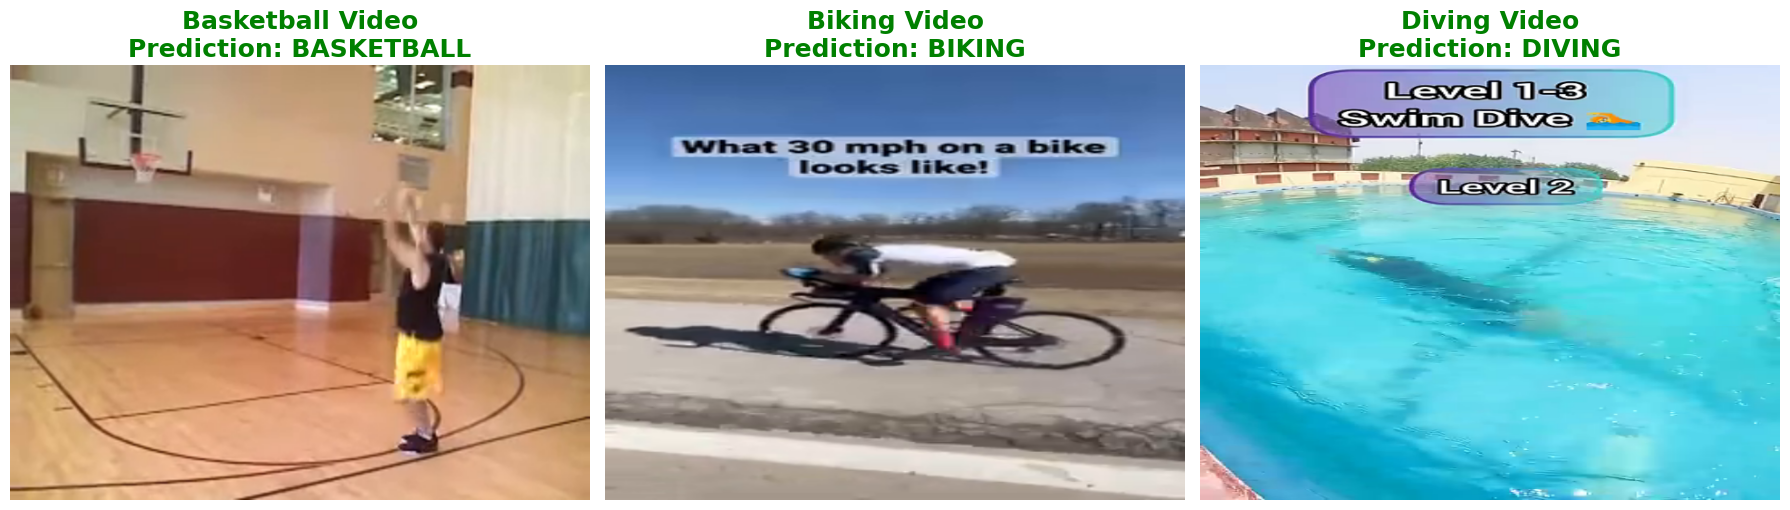

In [9]:
import yt_dlp
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output
from collections import Counter

def download_youtube_video(youtube_url, input_filename):
    ydl_opts = {
        'format': 'best[ext=mp4]/best', 
        'outtmpl': input_filename, 
        'quiet': True,
        'no_warnings': True
    }
    if os.path.exists(input_filename):
        os.remove(input_filename)
        
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([youtube_url])
    except Exception as e:
        print(f"Failed to download {youtube_url}: {e}")
        
    return input_filename

def process_video_and_get_photo(video_file_path, title):
    print(f"Playing live preview for {title}...")
    
    if not os.path.exists(video_file_path):
        print(f"Error: {video_file_path} failed to download.")
        return None, None
        
    video_reader = cv2.VideoCapture(video_file_path)
    
    # Find the middle of the video to grab the best photo
    total_frames = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    middle_frame_target = max(total_frames // 2, 1)
    current_frame_idx = 0
    
    frames_queue = []
    all_predictions = [] # We will store ALL predictions here
    predicted_class_name = 'Processing...'
    best_frame = None
    
    while video_reader.isOpened():
        ok, frame = video_reader.read() 
        if not ok: break
            
        current_frame_idx += 1
            
        resized_frame = cv2.resize(frame, (IMAGE_HEIGHT, IMAGE_WIDTH))
        normalized_frame = resized_frame / 255.0
        frames_queue.append(normalized_frame)
        
        if len(frames_queue) == SEQUENCE_LENGTH:
            predicted_probs = model.predict(np.expand_dims(frames_queue, axis=0), verbose=0)[0]
            predicted_label = np.argmax(predicted_probs)
            predicted_class_name = CLASSES_LIST[predicted_label]
            
            # Record the prediction vote
            all_predictions.append(predicted_class_name)
            frames_queue.pop(0) 
            
        # Grab the frame right in the middle of the action
        if current_frame_idx == middle_frame_target:
            best_frame = cv2.resize(frame, (640, 480))
            
        # LIVE PREVIEW
        display_frame = cv2.resize(frame.copy(), (480, 360))
        cv2.putText(display_frame, predicted_class_name.upper(), (15, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
        
        _, ret = cv2.imencode('.jpg', display_frame)
        img = Image(data=ret)
        
        clear_output(wait=True)
        display(img)
        
    video_reader.release()
    
    # Fallback if video was too short
    if best_frame is None and current_frame_idx > 0:
        best_frame = cv2.resize(frame, (640, 480))
        
    # Get the MOST COMMON prediction over the whole video (The smartest way!)
    if len(all_predictions) > 0:
        final_prediction = max(set(all_predictions), key=all_predictions.count)
    else:
        final_prediction = "Unknown"
    
    # Prepare the static photo
    if best_frame is not None:
        best_frame_rgb = cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)
        return best_frame_rgb, final_prediction
    else:
        return None, None

# --- Main Execution ---

final_photos = []

# 1. Basketball
download_youtube_video('https://youtu.be/Yzt7JDOuMhY', 'test_basketball.mp4')
photo1, pred1 = process_video_and_get_photo('test_basketball.mp4', 'Basketball')
if photo1 is not None: final_photos.append((photo1, 'Basketball Video', pred1))

# 2. Biking
download_youtube_video('https://youtube.com/shorts/FLeRVQAAwg8', 'test_biking.mp4')
photo2, pred2 = process_video_and_get_photo('test_biking.mp4', 'Biking')
if photo2 is not None: final_photos.append((photo2, 'Biking Video', pred2))

# 3. Diving
download_youtube_video('https://youtube.com/shorts/a25h-4wy57o', 'test_diving.mp4')
photo3, pred3 = process_video_and_get_photo('test_diving.mp4', 'Diving')
if photo3 is not None: final_photos.append((photo3, 'Diving Video', pred3))

# --- Print Final Guaranteed Gallery ---
clear_output(wait=True)
print("Live previews complete!")

if len(final_photos) > 0:
    plt.figure(figsize=(18, 6))
    for i, (img, title, pred) in enumerate(final_photos):
        plt.subplot(1, len(final_photos), i + 1)
        plt.imshow(img)
        plt.title(f"{title}\nPrediction: {pred.upper()}", fontsize=18, fontweight='bold', color='green')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: No photos were generated.")